# 01. Regression Adjustment

Randomized experiments solve the hardest part of causal inference by design: treatment assignment is independent of potential outcomes. In industry work, however, many important questions are observational. We want to know whether a sales intervention, retention campaign, pricing change, recommendation policy, loan offer, or support program caused a change in outcomes even though treatment was assigned by teams, algorithms, eligibility rules, or user behavior.

Regression adjustment is one of the first tools people reach for in that setting. It is familiar, flexible, and easy to explain. But it is also easy to misuse. A regression coefficient becomes part of a causal analysis only after we have a defensible adjustment strategy.

This notebook treats regression adjustment as a causal workflow, not just a modeling recipe.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain the difference between an associational regression and a causal regression adjustment.
- State the assumptions needed for regression adjustment to identify an average treatment effect.
- Diagnose observed confounding using covariate balance and treatment-overlap summaries.
- Estimate treatment effects with outcome regression and g-computation.
- Explain why a treatment coefficient can be misleading when the model includes interactions.
- Recognize bad controls such as mediators, colliders, and post-treatment variables.
- Translate a regression adjustment analysis into an industry decision readout.

In [1]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.special import expit
from graphviz import Digraph
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 3)

from notebooks._shared.display import smart_display

In [2]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """
    Create a styled Graphviz causal or design diagram for the lecture.
    
    Idea:
        The diagram makes assumptions, assignment mechanisms, and diagnostic workflows visible before the code estimates an effect.
    
    Args:
        edges: Directed edges from source node to target node in the causal or design diagram.
        title: Title displayed on the Graphviz or Matplotlib figure.
        node_colors: Optional mapping from node labels to fill colors.
        rankdir: Graphviz layout direction, such as left-to-right or top-to-bottom.
    
    Returns:
        graphviz.Digraph: Renderable diagram object for display in the notebook.
    """
    node_colors = node_colors or {}
    dot = Digraph(format="svg")
    dot.attr(rankdir=rankdir, bgcolor="transparent", pad="0.2")
    dot.attr("graph", labelloc="t", fontsize="18", fontname="DejaVu Sans")
    if title:
        dot.attr(label=title)
    dot.attr("node", shape="box", style="rounded,filled", fontname="DejaVu Sans", fontsize="11", margin="0.12,0.08", color="#334155")
    dot.attr("edge", color="#475569", arrowsize="0.8", fontname="DejaVu Sans", fontsize="10")
    nodes = sorted(set([u for u, _ in edges] + [v for _, v in edges]))
    for node in nodes:
        fill = node_colors.get(node, "#f8fafc")
        dot.node(node, fillcolor=fill)
    for u, v in edges:
        dot.edge(u, v)
    return dot


def standardized_mean_differences(frame, covariates, treatment="treated"):
    """
    Compute standardized mean differences for pre-treatment covariates.
    
    Idea:
        SMDs put covariate imbalance on a common scale so diagnostics can be compared before and after adjustment or weighting.
    
    Args:
        frame: Analysis DataFrame containing the treatment, outcome, score, or covariate columns used by the helper.
        covariates: Pre-treatment covariate columns evaluated for balance or adjustment.
        treatment: Treatment column or treatment value used to define the causal contrast.
    
    Returns:
        pandas.DataFrame: Balance diagnostics for each covariate, including treated and comparison summaries.
    """
    rows = []
    treated = frame[treatment] == 1
    control = frame[treatment] == 0
    for col in covariates:
        mt = frame.loc[treated, col].mean()
        mc = frame.loc[control, col].mean()
        vt = frame.loc[treated, col].var(ddof=1)
        vc = frame.loc[control, col].var(ddof=1)
        pooled_sd = np.sqrt((vt + vc) / 2)
        smd = np.nan if pooled_sd == 0 else (mt - mc) / pooled_sd
        rows.append({
            "covariate": col,
            "treated_mean": mt,
            "control_mean": mc,
            "smd": smd,
            "abs_smd": abs(smd),
        })
    return pd.DataFrame(rows).sort_values("abs_smd", ascending=False)


def coefficient_table(models, term="treated", true_value=None):
    """
    Extract treatment coefficients and robust intervals from fitted regression models.
    
    Idea:
        This keeps model comparisons focused on how adjustment changes the estimated causal contrast.
    
    Args:
        models: Mapping of model labels to fitted statsmodels regression results.
        term: Coefficient name to extract from each fitted regression model.
        true_value: Reference value shown beside estimates when the simulation has a known truth.
    
    Returns:
        pandas.DataFrame: One row per model with estimate, robust standard error, confidence interval, and reference value.
    """
    rows = []
    for label, model in models.items():
        ci = model.conf_int().loc[term]
        rows.append({
            "model": label,
            "estimate": model.params[term],
            "std_error": model.bse[term],
            "ci_low": ci.iloc[0],
            "ci_high": ci.iloc[1],
        })
    out = pd.DataFrame(rows)
    if true_value is not None:
        out["true_ate"] = true_value
        out["bias_vs_true_ate"] = out["estimate"] - true_value
    return out


def plot_effect_table(effect_table, title, xlabel, reference=None, figsize=(8, 3.8)):
    """Plot effect estimates and uncertainty intervals for model comparisons.

    Args:
        effect_table: Effect-summary table with estimates and uncertainty intervals.
        title: Title shown on the resulting figure.
        xlabel: X-axis label for the resulting figure.
        reference: Reference value or omitted event time used for interpretation.
        figsize: Matplotlib figure size.

    Returns:
        tuple: Matplotlib figure and axes containing effect estimates.
    """
    fig, ax = plt.subplots(figsize=figsize)
    plot_df = effect_table.iloc[::-1].reset_index(drop=True)
    y = np.arange(len(plot_df))
    x = plot_df["estimate"]
    lower = x - plot_df["ci_low"]
    upper = plot_df["ci_high"] - x
    ax.errorbar(x, y, xerr=[lower, upper], fmt="o", color="#2563eb", ecolor="#93c5fd", capsize=4)
    if reference is not None:
        ax.axvline(reference, color="#dc2626", linestyle="--", linewidth=1.5, label="True ATE")
        ax.legend(frameon=False, loc="lower right")
    ax.axvline(0, color="#64748b", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["model"])
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    sns.despine(ax=ax)
    plt.show()


def g_computation(model, data, treatment="treated", subset=None):
    """
    Standardize fitted potential-outcome predictions over a target population.
    
    Idea:
        The function predicts each unit twice, once as treated and once as untreated, then averages the contrast over the chosen target sample.
    
    Args:
        model: Fitted outcome model used to generate potential-outcome predictions.
        data: Analysis DataFrame containing the variables required by the model or diagnostic.
        treatment: Treatment column or treatment value used to define the causal contrast.
        subset: Optional subset of rows defining the target population for standardization.
    
    Returns:
        dict: Standardized potential outcome means and their treatment-effect contrast.
    """
    target = data if subset is None else data.loc[subset].copy()
    d1 = target.copy()
    d0 = target.copy()
    d1[treatment] = 1
    d0[treatment] = 0
    mu1 = model.predict(d1)
    mu0 = model.predict(d0)
    effects = np.asarray(mu1 - mu0)
    return {
        "mean_y1_hat": float(np.mean(mu1)),
        "mean_y0_hat": float(np.mean(mu0)),
        "ate_hat": float(np.mean(effects)),
        "median_individual_effect_hat": float(np.median(effects)),
        "effect_sd_hat": float(np.std(effects, ddof=1)),
    }

## 1. From Experiments to Observational Adjustment

In an experiment, treatment is assigned by a known random mechanism. In an observational study, treatment is assigned by a process that usually depends on customer characteristics, operational rules, clinician judgment, product behavior, or policy eligibility.

That difference changes the meaning of a regression.

A predictive regression asks:

$$
E[Y \mid D, X]
$$

A causal adjustment asks whether we can use the conditional outcome relationship to recover missing potential outcomes:

$$
Y_i(1), \quad Y_i(0)
$$

where unit `i` receives either treatment `D_i = 1` or control `D_i = 0`, but never both at the same time.

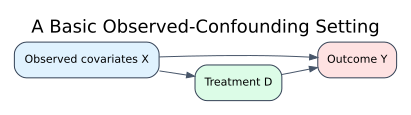

In [3]:
# Define the graph structure for the From Experiments to Observational Adjustment diagram.
adjustment_edges = [
    ("Observed covariates X", "Treatment D"),
    ("Observed covariates X", "Outcome Y"),
    ("Treatment D", "Outcome Y"),
]

node_colors = {
    "Observed covariates X": "#e0f2fe",
    "Treatment D": "#dcfce7",
    "Outcome Y": "#fee2e2",
}

smart_display(make_dag(adjustment_edges, "A Basic Observed-Confounding Setting", node_colors=node_colors))

The backdoor path from `Treatment D` to `Outcome Y` goes through the observed covariates `X`. If high-risk customers are more likely to receive a retention intervention and also more likely to churn, a raw comparison of treated and untreated customers is not a causal effect.

Regression adjustment tries to compare treated and untreated units at the same values of `X`. That is the key idea. The regression is a tool for constructing conditional comparisons; it is not, by itself, the source of causal validity.

## 2. The Identification Assumptions

For a binary treatment, the average treatment effect is:

$$
ATE = E[Y(1) - Y(0)]
$$

Regression adjustment identifies this quantity under assumptions that are causal, not merely statistical.

### Consistency

If a unit receives treatment level `d`, its observed outcome equals the corresponding potential outcome:

$$
Y_i = D_iY_i(1) + (1-D_i)Y_i(0)
$$

### Conditional Exchangeability

After conditioning on observed pre-treatment covariates, treatment assignment is as good as random:

$$
(Y_i(1), Y_i(0)) \perp D_i \mid X_i
$$

This is also called no unmeasured confounding, selection on observables, or unconfoundedness.

### Positivity / Overlap

Every covariate profile in the target population has some chance of receiving each treatment level:

$$
0 < P(D_i=1 \mid X_i=x) < 1
$$

### Correct Enough Outcome Model

If we use a regression model to estimate conditional outcomes, the model must be rich enough for the adjustment task. It does not need to be perfect for prediction everywhere, but it must estimate the relevant conditional mean contrasts well.

Rubin's potential-outcomes framework formalized the comparison of treatment and control potential outcomes in randomized and nonrandomized studies (Rubin, 1974). Rosenbaum and Rubin (1983) formalized strongly ignorable treatment assignment and the role of balancing scores in observational studies. Imbens (2004) reviews average-treatment-effect estimation under exogeneity-type assumptions.

## 3. A Running Industry Example

Suppose a SaaS company has a customer-success program. Account managers proactively contact customers who appear at risk of churn or contraction. The business question is:

> What is the causal effect of proactive customer-success outreach on next-quarter account health?

This is observational because outreach is targeted. High-risk customers are more likely to receive outreach. A naive treated-versus-untreated comparison will mix the effect of outreach with the fact that treated customers were different before outreach.

We will simulate data where we know the true treatment effect. That lets us see exactly where adjustment helps and where it can fail.

**Dataset and experiment setup.** The running example represents customers who may receive customer-success outreach. Each row is a customer with pre-treatment characteristics such as account size, baseline risk, usage, tenure, and support history. Outreach is targeted toward customers who look more valuable or more at risk, so treatment assignment is confounded by design. The outcome is a post-period renewal or revenue measure. The simulation keeps the true treatment effect available for checking, but the analysis behaves as if we only observed the treatment, covariates, and outcome. This is the core observational-adjustment problem.

In [4]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def simulate_customer_success(n=8000, seed=1000):
    """Generate an observational customer-success outreach dataset with measured confounding.

    Args:
        n: Number of simulated units.
        seed: Random seed for reproducible simulation or resampling.

    Returns:
        pandas.DataFrame: Simulated dataset with observed variables and any known truth columns used for teaching.
    """
    rng = np.random.default_rng(seed)

    plan = rng.choice(["startup", "growth", "enterprise"], p=[0.42, 0.38, 0.20], size=n)
    plan_effect = pd.Series(plan).map({"startup": 0.0, "growth": 3.0, "enterprise": 7.0}).to_numpy()

    tenure = np.clip(rng.gamma(shape=2.2, scale=7.0, size=n), 1, 48)
    usage = np.clip(rng.normal(50 + 0.6 * tenure + 2.0 * plan_effect, 12, n), 5, 120)
    pre_value = np.clip(rng.normal(80 + 1.2 * tenure + 5.0 * plan_effect, 18, n), 20, 220)

    risk_score = expit(1.4 - 0.045 * usage - 0.012 * pre_value + rng.normal(0, 0.8, n))

    treatment_probability = expit(
        -2.0
        + 4.2 * risk_score
        + 0.45 * (plan == "enterprise")
        + 0.25 * (plan == "growth")
        - 0.008 * tenure
    )
    treated = rng.binomial(1, treatment_probability)

    y0 = (
        62
        + 0.10 * pre_value
        + 0.18 * tenure
        + 0.22 * usage
        + plan_effect
        - 22 * risk_score
        + 8 * risk_score**2
        + rng.normal(0, 4.5, n)
    )

    individual_effect = (
        3.0
        + 1.00 * (plan == "enterprise")
        + 0.45 * (plan == "growth")
        - 1.40 * risk_score
        + 0.012 * usage
    )

    outcome = y0 + individual_effect * treated

    df = pd.DataFrame({
        "plan": plan,
        "tenure": tenure,
        "usage": usage,
        "pre_value": pre_value,
        "risk_score": risk_score,
        "treatment_probability": treatment_probability,
        "treated": treated,
        "y0": y0,
        "true_individual_effect": individual_effect,
        "outcome": outcome,
    })
    return df


df = simulate_customer_success()
for col in ["pre_value", "tenure", "usage", "risk_score"]:
    df[f"{col}_c"] = df[col] - df[col].mean()

true_ate = df["true_individual_effect"].mean()
true_att = df.loc[df["treated"] == 1, "true_individual_effect"].mean()

summary = pd.DataFrame({
    "quantity": [
        "Number of accounts",
        "Share receiving outreach",
        "True ATE in the simulated population",
        "True ATT among accounts that received outreach",
        "Mean observed account health",
    ],
    "value": [
        len(df),
        df["treated"].mean(),
        true_ate,
        true_att,
        df["outcome"].mean(),
    ],
})

smart_display(summary)
smart_display(df.head())

,quantity,value
0,Number of accounts,8000.000000
1,Share receiving outreach,0.183250
2,True ATE in the simulated population,4.016746
3,True ATT among accounts that received outreach,3.942602
4,Mean observed account health,91.284459


,plan,tenure,usage,pre_value,risk_score,treatment_probability,treated,y0,true_individual_effect,outcome,pre_value_c,tenure_c,usage_c,risk_score_c
0,growth,7.258,66.599,86.411,0.086,0.190,0,86.460,4.129,86.460,-24.214,-7.873,2.446,-0.003
1,growth,3.377,70.184,95.393,0.039,0.166,0,83.975,4.237,83.975,-15.232,-11.754,6.031,-0.049
2,growth,18.903,36.212,88.188,0.613,0.663,0,69.886,3.026,69.886,-22.436,3.772,-27.941,0.525
3,startup,24.080,82.906,129.777,0.010,0.104,0,96.486,3.981,96.486,19.153,8.949,18.753,-0.079
4,growth,16.550,80.706,132.081,0.032,0.148,0,101.558,4.373,101.558,21.456,1.419,16.554,-0.056


The true ATE is known only because this is a simulation. In a real project, the true potential outcomes are not observed. We use the simulation to learn how different estimators behave when the assignment process is targeted.

The share receiving outreach is much smaller than one half. This already looks like a targeted program rather than a balanced experiment. That is common in industry: interventions are expensive, constrained by capacity, or triggered by risk scores.

## 4. The Naive Comparison

The naive estimator compares observed outcomes among treated and untreated customers:

$$
E[Y \mid D=1] - E[Y \mid D=0]
$$

This observed contrast requires adjustment because treated and untreated customers may have different potential outcomes even before treatment.

In [5]:
# Build the summary table used to connect the calculation back to the design question.
group_summary = (
    df.groupby("treated")
    .agg(
        accounts=("outcome", "size"),
        mean_outcome=("outcome", "mean"),
        mean_risk=("risk_score", "mean"),
        mean_usage=("usage", "mean"),
        mean_pre_value=("pre_value", "mean"),
        mean_tenure=("tenure", "mean"),
    )
    .rename(index={0: "No outreach", 1: "Outreach"})
)

naive_effect = group_summary.loc["Outreach", "mean_outcome"] - group_summary.loc["No outreach", "mean_outcome"]

comparison = pd.DataFrame({
    "estimand_or_estimator": ["Naive difference in observed means", "True ATE", "True ATT"],
    "value": [naive_effect, true_ate, true_att],
})

smart_display(group_summary)
smart_display(comparison)

,accounts,mean_outcome,mean_risk,mean_usage,mean_pre_value,mean_tenure
treated,,,,,,
No outreach,6534,90.948,0.081,64.748,111.117,15.440
Outreach,1466,92.784,0.121,61.500,108.429,13.753


,estimand_or_estimator,value
0,Naive difference in observed means,1.836540
1,True ATE,4.016746
2,True ATT,3.942602


The treated accounts have different baseline characteristics. They tend to have higher risk and different usage/value profiles. The naive difference is therefore a mixture of two things:

- The causal effect of outreach.
- Pre-existing differences between customers who were selected for outreach and those who were not.

This is selection bias. The direction can be positive or negative depending on how treatment is targeted. Here the naive comparison understates the benefit because outreach is directed toward accounts with worse potential outcomes.

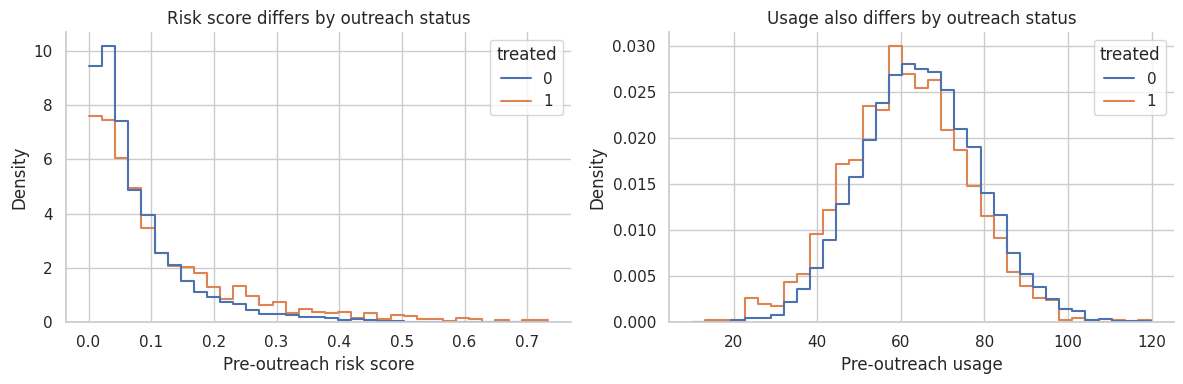

In [6]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=df,
    x="risk_score",
    hue="treated",
    stat="density",
    common_norm=False,
    bins=35,
    element="step",
    fill=False,
    ax=axes[0],
)
axes[0].set_title("Risk score differs by outreach status")
axes[0].set_xlabel("Pre-outreach risk score")

sns.histplot(
    data=df,
    x="usage",
    hue="treated",
    stat="density",
    common_norm=False,
    bins=35,
    element="step",
    fill=False,
    ax=axes[1],
)
axes[1].set_title("Usage also differs by outreach status")
axes[1].set_xlabel("Pre-outreach usage")

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

The two distributions differ. This is the visual version of confounding. If risk and usage also affect account health, then outreach status is carrying information about the customer's untreated potential outcome.

Regression adjustment is an attempt to remove this observed imbalance by comparing customers at similar risk, usage, value, tenure, and plan tier.

,covariate,treated_mean,control_mean,smd,abs_smd
0,risk_score,0.121,0.081,0.372,0.372
1,usage,61.500,64.748,-0.227,0.227
3,tenure,13.753,15.440,-0.173,0.173
2,pre_value,108.429,111.117,-0.107,0.107
5,plan_growth,0.372,0.389,-0.033,0.033
4,plan_enterprise,0.206,0.195,0.027,0.027
6,plan_startup,0.422,0.416,0.011,0.011


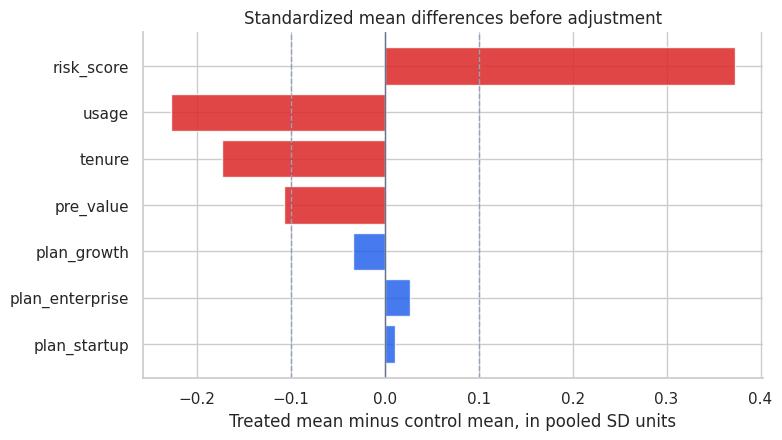

In [7]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
plan_dummies = pd.get_dummies(df["plan"], prefix="plan", dtype=float)
balance_frame = pd.concat(
    [df[["treated", "risk_score", "usage", "pre_value", "tenure"]], plan_dummies],
    axis=1,
)
balance_covariates = [c for c in balance_frame.columns if c != "treated"]
smd = standardized_mean_differences(balance_frame, balance_covariates)

smart_display(smd)

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = smd.sort_values("abs_smd", ascending=True)
colors = np.where(plot_df["abs_smd"] >= 0.10, "#dc2626", "#2563eb")
ax.barh(plot_df["covariate"], plot_df["smd"], color=colors, alpha=0.85)
ax.axvline(0, color="#64748b", linewidth=1)
ax.axvline(0.10, color="#94a3b8", linestyle="--", linewidth=1)
ax.axvline(-0.10, color="#94a3b8", linestyle="--", linewidth=1)
ax.set_title("Standardized mean differences before adjustment")
ax.set_xlabel("Treated mean minus control mean, in pooled SD units")
sns.despine(ax=ax)
plt.show()

Standardized mean differences put covariate imbalance on a comparable scale. A common rough diagnostic is that absolute values above 0.10 deserve attention, although the threshold is not a law of nature.

Here, several pre-treatment covariates are imbalanced. A regression that ignores these covariates is asking the wrong comparison question.

## 5. Outcome Regression Adjustment

The simplest regression adjustment estimates a conditional mean model:

$$
E[Y \mid D, X] = \alpha + \tau D + f(X)
$$

If the causal assumptions hold and the model is correctly specified for the adjustment task, the coefficient on `D` can estimate a causal effect. But this statement has many conditions hidden inside it.

Let's compare a sequence of models.

,model,estimate,std_error,ci_low,ci_high,true_ate,bias_vs_true_ate
0,Unadjusted regression,1.837,0.297,1.255,2.418,4.017,-2.180
1,"Adjust value, tenure, plan",2.688,0.182,2.331,3.045,4.017,-1.329
2,Adjust main confounders,3.877,0.133,3.617,4.137,4.017,-0.139
3,Add risk curvature,3.869,0.133,3.609,4.130,4.017,-0.147


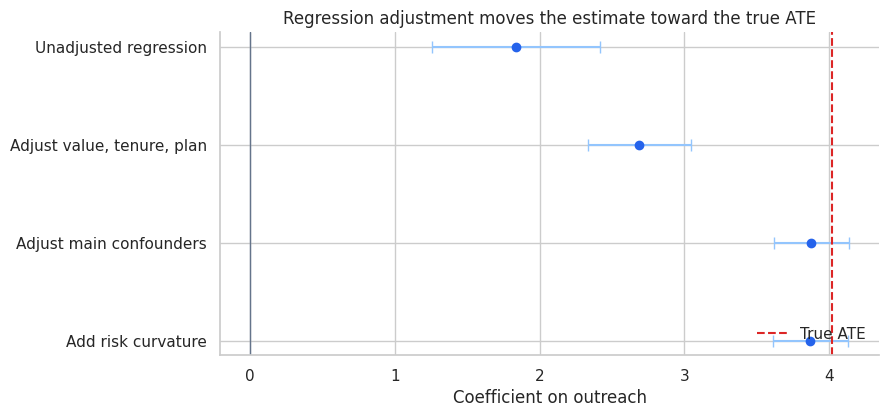

In [8]:
# Fit the statistical model and collect estimates used in the following interpretation.
models = {
    "Unadjusted regression": smf.ols(
        "outcome ~ treated",
        data=df,
    ).fit(cov_type="HC3"),
    "Adjust value, tenure, plan": smf.ols(
        "outcome ~ treated + pre_value + tenure + C(plan)",
        data=df,
    ).fit(cov_type="HC3"),
    "Adjust main confounders": smf.ols(
        "outcome ~ treated + pre_value + tenure + usage + risk_score + C(plan)",
        data=df,
    ).fit(cov_type="HC3"),
    "Add risk curvature": smf.ols(
        "outcome ~ treated + pre_value + tenure + usage + risk_score + I(risk_score ** 2) + C(plan)",
        data=df,
    ).fit(cov_type="HC3"),
}

coef_results = coefficient_table(models, true_value=true_ate)
smart_display(coef_results)

plot_effect_table(
    coef_results,
    title="Regression adjustment moves the estimate toward the true ATE",
    xlabel="Coefficient on outreach",
    reference=true_ate,
    figsize=(8.5, 4.2),
)

The unadjusted regression is the same estimand as the naive mean difference. It is just written as a regression.

As we add meaningful pre-treatment covariates, the estimate moves closer to the true ATE. The key word is meaningful. Adding variables because they are available is not a causal strategy. The variables should be justified by a causal story: they affect treatment assignment and the outcome, and they are measured before treatment.

The standard errors above use a heteroskedasticity-robust covariance estimator (`HC3`). Robust standard errors do not fix confounding or model misspecification, but they are a sensible default for many OLS readouts.

## 6. What the Regression Is Comparing

A useful way to explain regression adjustment to stakeholders is this:

> We are comparing predicted outcomes under outreach and no outreach for customers with the same observed pre-treatment characteristics.

Let's inspect model predictions for a few customer profiles.

In [9]:
# Build the summary table used to connect the calculation back to the design question.
profile_model = models["Add risk curvature"]

profiles = pd.DataFrame({
    "plan": ["startup", "growth", "enterprise", "enterprise"],
    "tenure": [6.0, 14.0, 20.0, 20.0],
    "usage": [35.0, 55.0, 75.0, 45.0],
    "pre_value": [70.0, 105.0, 155.0, 155.0],
    "risk_score": [0.45, 0.25, 0.12, 0.42],
})

d1 = profiles.copy()
d0 = profiles.copy()
d1["treated"] = 1
d0["treated"] = 0

profile_predictions = profiles.copy()
profile_predictions.insert(0, "profile", np.arange(1, len(profiles) + 1))
profile_predictions["predicted_y_if_outreach"] = profile_model.predict(d1)
profile_predictions["predicted_y_if_no_outreach"] = profile_model.predict(d0)
profile_predictions["predicted_difference"] = (
    profile_predictions["predicted_y_if_outreach"]
    - profile_predictions["predicted_y_if_no_outreach"]
)

smart_display(profile_predictions)

,profile,plan,tenure,usage,pre_value,risk_score,predicted_y_if_outreach,predicted_y_if_no_outreach,predicted_difference
0,1,startup,6.0,35.0,70.0,0.45,72.724,68.855,3.869
1,2,growth,14.0,55.0,105.0,0.25,88.885,85.016,3.869
2,3,enterprise,20.0,75.0,155.0,0.12,106.069,102.199,3.869
3,4,enterprise,20.0,45.0,155.0,0.42,93.814,89.944,3.869


In this additive model, the treatment difference is the same for every profile because the model contains no treatment-covariate interactions. That may be appropriate if the treatment effect is roughly constant. But in many industry settings, intervention effects differ by customer segment, risk, channel, geography, or product maturity.

When treatment effects are heterogeneous, the single treatment coefficient is often too compressed. We need to decide which population we want to average over.

## 7. G-Computation: Averaging Predicted Potential Outcomes

Regression adjustment can be expressed through the g-computation formula. First estimate the conditional outcome functions:

$$
m_1(x) = E[Y \mid D=1, X=x]
$$

$$
m_0(x) = E[Y \mid D=0, X=x]
$$

Then average their difference over the target population:

$$
ATE = E[m_1(X) - m_0(X)]
$$

This is often clearer than asking whether a single regression coefficient is causal. It also generalizes naturally to models with interactions, nonlinearities, and machine learning outcome models.

In [10]:
# Fit the statistical model and collect estimates used in the following interpretation.
heterogeneous_model = smf.ols(
    "outcome ~ treated * (usage_c + risk_score_c + C(plan)) + "
    "pre_value_c + tenure_c + usage_c + risk_score_c + I(risk_score_c ** 2) + C(plan)",
    data=df,
).fit(cov_type="HC3")

gcomp_population = g_computation(heterogeneous_model, df)
gcomp_treated = g_computation(heterogeneous_model, df, subset=df["treated"] == 1)

heterogeneous_summary = pd.DataFrame({
    "quantity": [
        "Treatment coefficient in interaction model",
        "G-computation ATE over all accounts",
        "G-computation ATT over treated accounts",
        "True ATE",
        "True ATT",
    ],
    "value": [
        heterogeneous_model.params["treated"],
        gcomp_population["ate_hat"],
        gcomp_treated["ate_hat"],
        true_ate,
        true_att,
    ],
})

smart_display(heterogeneous_summary)

,quantity,value
0,Treatment coefficient in interaction model,4.230186
1,G-computation ATE over all accounts,3.943956
2,G-computation ATT over treated accounts,3.809995
3,True ATE,4.016746
4,True ATT,3.942602


Once the model includes interactions, the coefficient on `treated` represents the estimated treatment effect for a particular reference profile determined by the formula coding. With centered numeric covariates, it is closer to an average-profile effect for the reference plan category. The population ATE still requires averaging predicted contrasts over the target population.

G-computation answers the estimand directly: predict each account twice, once under outreach and once under no outreach, then average the contrast over the population of interest.

This is a major practical point. In causal notebooks and stakeholder decks, prefer to show the standardized causal contrast rather than relying only on the raw treatment coefficient.

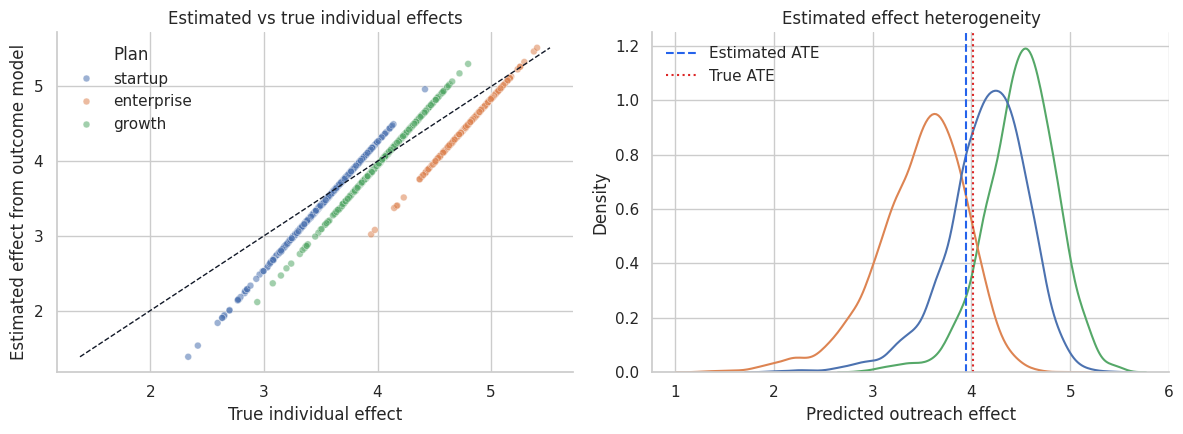

In [11]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
d1 = df.copy()
d0 = df.copy()
d1["treated"] = 1
d0["treated"] = 0

df_effects = df.copy()
df_effects["estimated_effect"] = heterogeneous_model.predict(d1) - heterogeneous_model.predict(d0)

sample_effects = df_effects.sample(1600, random_state=17)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.scatterplot(
    data=sample_effects,
    x="true_individual_effect",
    y="estimated_effect",
    hue="plan",
    alpha=0.55,
    s=24,
    ax=axes[0],
)
lo = min(sample_effects["true_individual_effect"].min(), sample_effects["estimated_effect"].min())
hi = max(sample_effects["true_individual_effect"].max(), sample_effects["estimated_effect"].max())
axes[0].plot([lo, hi], [lo, hi], color="#111827", linestyle="--", linewidth=1)
axes[0].set_title("Estimated vs true individual effects")
axes[0].set_xlabel("True individual effect")
axes[0].set_ylabel("Estimated effect from outcome model")
axes[0].legend(title="Plan", frameon=False)

sns.kdeplot(
    data=df_effects,
    x="estimated_effect",
    hue="plan",
    common_norm=False,
    fill=False,
    ax=axes[1],
)
axes[1].axvline(gcomp_population["ate_hat"], color="#2563eb", linestyle="--", label="Estimated ATE")
axes[1].axvline(true_ate, color="#dc2626", linestyle=":", label="True ATE")
axes[1].set_title("Estimated effect heterogeneity")
axes[1].set_xlabel("Predicted outreach effect")
axes[1].legend(frameon=False)

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

The model captures the broad pattern of heterogeneity, but it is not perfect. That is realistic. Regression adjustment is an approximation to missing potential outcomes, and the quality of the causal estimate depends on the quality of the adjustment set, overlap, and outcome model.

The plot emphasizes population and segment averages rather than individual treatment effects, which are usually too ambitious. A defensible analysis pairs those averages with diagnostics about whether the comparison is credible.

## 8. Model Specification Matters

A regression adjustment can fail in two different ways:

1. The adjustment set is causally wrong because important confounders are missing or bad controls are included.
2. The adjustment set is right, but the outcome model is too rigid for the observed relationships.

The first problem is identification. The second problem is estimation.

,specification,treatment_coefficient,gcomp_ate,bias_of_gcomp
0,"Only value, tenure, plan",2.687639,2.687639,-1.329108
1,Add observed risk and usage,3.877278,3.877278,-0.139469
2,Add risk curvature,3.869299,3.869299,-0.147447
3,Interactions plus g-computation,4.230186,3.943956,-0.072790


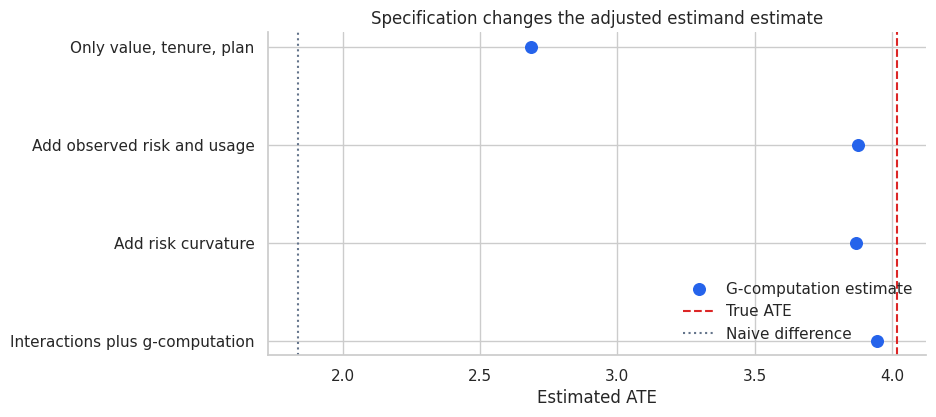

In [12]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
spec_rows = []
for label, formula in {
    "Only value, tenure, plan": "outcome ~ treated + pre_value + tenure + C(plan)",
    "Add observed risk and usage": "outcome ~ treated + pre_value + tenure + usage + risk_score + C(plan)",
    "Add risk curvature": "outcome ~ treated + pre_value + tenure + usage + risk_score + I(risk_score ** 2) + C(plan)",
    "Interactions plus g-computation": "outcome ~ treated * (usage_c + risk_score_c + C(plan)) + pre_value_c + tenure_c + usage_c + risk_score_c + I(risk_score_c ** 2) + C(plan)",
}.items():
    model = smf.ols(formula, data=df).fit(cov_type="HC3")
    gcomp = g_computation(model, df)["ate_hat"]
    spec_rows.append({
        "specification": label,
        "treatment_coefficient": model.params["treated"],
        "gcomp_ate": gcomp,
        "bias_of_gcomp": gcomp - true_ate,
    })

spec_table = pd.DataFrame(spec_rows)
smart_display(spec_table)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
plot_df = spec_table.iloc[::-1]
ax.scatter(plot_df["gcomp_ate"], plot_df["specification"], s=70, color="#2563eb", label="G-computation estimate")
ax.axvline(true_ate, color="#dc2626", linestyle="--", linewidth=1.5, label="True ATE")
ax.axvline(naive_effect, color="#64748b", linestyle=":", linewidth=1.5, label="Naive difference")
ax.set_xlabel("Estimated ATE")
ax.set_title("Specification changes the adjusted estimand estimate")
ax.legend(frameon=False, loc="lower right")
sns.despine(ax=ax)
plt.show()

The model that omits risk and usage still adjusts for some pre-treatment differences, but it does not adjust for the variables most responsible for targeted outreach. It remains biased.

Adding the main confounders improves the estimate. Adding a more flexible functional form and using g-computation makes the causal target explicit.

This is why a professional regression adjustment notebook should include sensitivity to reasonable specifications. A single adjusted regression table is rarely enough.

## 9. Overlap: Regression Can Extrapolate Quietly

Regression produces a number even when treated and untreated units are not comparable. If high-risk accounts are almost always treated and low-risk accounts are almost never treated, the model must extrapolate across regions with little data support.

In this simulation we know the true treatment probability. In real observational work, we estimate it with a propensity score model. The next lecture focuses on that directly.

,risk_bin,accounts,outreach_rate,mean_true_assignment_probability,mean_risk
0,"(-0.000312, 0.0157]",1000,0.143000,0.137148,0.009688
1,"(0.0157, 0.0271]",1000,0.149000,0.141784,0.021370
2,"(0.0271, 0.0405]",1000,0.148000,0.146965,0.033780
3,"(0.0405, 0.057]",1000,0.152000,0.152355,0.048410
4,"(0.057, 0.0797]",1000,0.175000,0.162087,0.067604
5,"(0.0797, 0.114]",1000,0.177000,0.176254,0.095816
6,"(0.114, 0.182]",1000,0.199000,0.206963,0.143967
7,"(0.182, 0.733]",1000,0.323000,0.320160,0.287192


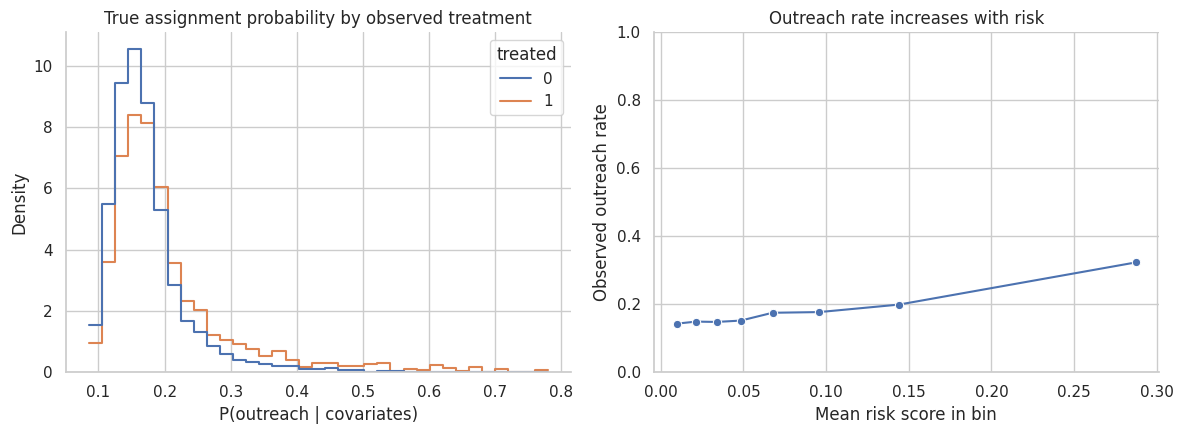

In [13]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
df["risk_bin"] = pd.qcut(df["risk_score"], q=8, duplicates="drop")
overlap_table = (
    df.groupby("risk_bin", observed=True)
    .agg(
        accounts=("outcome", "size"),
        outreach_rate=("treated", "mean"),
        mean_true_assignment_probability=("treatment_probability", "mean"),
        mean_risk=("risk_score", "mean"),
    )
    .reset_index()
)

smart_display(overlap_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(
    data=df,
    x="treatment_probability",
    hue="treated",
    stat="density",
    common_norm=False,
    bins=35,
    element="step",
    fill=False,
    ax=axes[0],
)
axes[0].set_title("True assignment probability by observed treatment")
axes[0].set_xlabel("P(outreach | covariates)")

sns.lineplot(
    data=overlap_table,
    x="mean_risk",
    y="outreach_rate",
    marker="o",
    ax=axes[1],
)
axes[1].set_ylim(0, 1)
axes[1].set_title("Outreach rate increases with risk")
axes[1].set_xlabel("Mean risk score in bin")
axes[1].set_ylabel("Observed outreach rate")

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

There is some overlap, but treatment is clearly concentrated among higher-risk customers. If the highest-risk bins had almost no untreated customers, regression adjustment would rely heavily on model extrapolation for the counterfactual no-outreach outcome in that region.

This is one reason analysts often pair regression adjustment with propensity score diagnostics, trimming rules, or doubly robust estimators.

## 10. Bad Controls: Do Not Adjust for Everything

A common mistake is to put every available variable into the regression. More controls can reduce or increase bias depending on their causal role.

For a total-effect question, pre-treatment confounders are usually candidates for adjustment. Post-treatment mediators are not, because they are part of the causal pathway. Colliders are also dangerous because conditioning on them can open noncausal paths.

Ho (2025) emphasizes that regression adjustment depends on identifying and measuring confounders and modeling them appropriately; subject knowledge is needed to decide whether a variable is a confounder, mediator, collider, or something else.

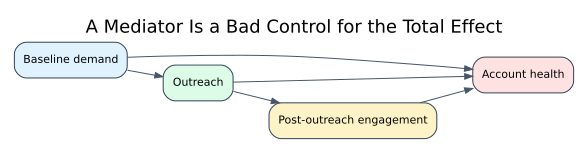

In [14]:
# Define the graph structure for the Bad Controls: Do Not Adjust for Everything diagram.
bad_control_edges = [
    ("Baseline demand", "Outreach"),
    ("Baseline demand", "Account health"),
    ("Outreach", "Post-outreach engagement"),
    ("Post-outreach engagement", "Account health"),
    ("Outreach", "Account health"),
]

bad_control_colors = {
    "Baseline demand": "#e0f2fe",
    "Outreach": "#dcfce7",
    "Post-outreach engagement": "#fef3c7",
    "Account health": "#fee2e2",
}

smart_display(make_dag(bad_control_edges, "A Mediator Is a Bad Control for the Total Effect", bad_control_colors))

If the estimand is the total effect of outreach, then post-outreach engagement is part of the mechanism. Controlling for it asks a different question: the direct effect of outreach not operating through engagement.

That may be a valid estimand in a mediation analysis, while the business question remains: "Should we do the outreach program?"

,quantity,value
0,True total effect,4.400000
1,Adjusted for pre-treatment demand only,4.432523
2,Adjusted for post-treatment engagement too,2.003069
3,True direct effect not through engagement,2.000000


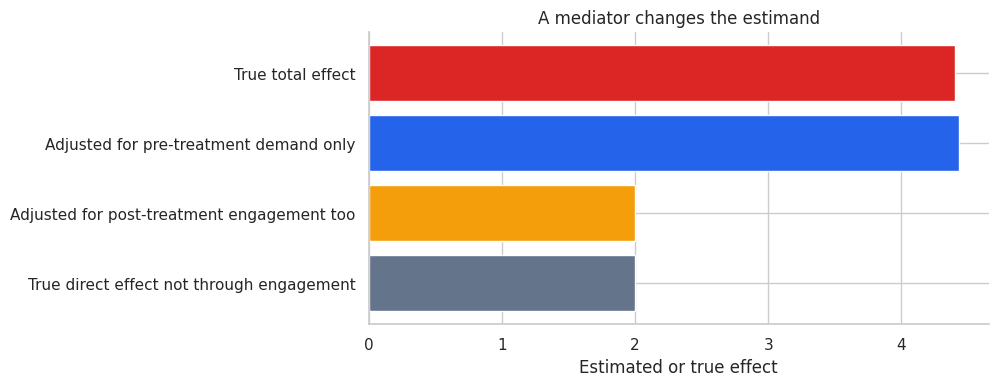

In [15]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def simulate_bad_control(seed=44, n=6000):
    """Generate a bad-control example where adjustment blocks part of the treatment effect.

    Args:
        seed: Random seed for reproducible simulation or resampling.
        n: Number of simulated units.

    Returns:
        pandas.DataFrame: Simulated dataset with observed variables and any known truth columns used for teaching.
    """
    rng = np.random.default_rng(seed)
    baseline_demand = rng.normal(0, 1, n)
    treated = rng.binomial(1, expit(-0.2 + 0.8 * baseline_demand))
    post_engagement = 0.8 * treated + 0.5 * baseline_demand + rng.normal(0, 1, n)
    outcome = 2.0 * treated + 3.0 * post_engagement + 1.4 * baseline_demand + rng.normal(0, 1, n)
    return pd.DataFrame({
        "baseline_demand": baseline_demand,
        "treated": treated,
        "post_engagement": post_engagement,
        "outcome": outcome,
    })

bad_df = simulate_bad_control()
true_total_effect = 2.0 + 3.0 * 0.8
true_direct_effect = 2.0

total_model = smf.ols("outcome ~ treated + baseline_demand", bad_df).fit(cov_type="HC3")
bad_control_model = smf.ols("outcome ~ treated + baseline_demand + post_engagement", bad_df).fit(cov_type="HC3")

bad_control_results = pd.DataFrame({
    "quantity": [
        "True total effect",
        "Adjusted for pre-treatment demand only",
        "Adjusted for post-treatment engagement too",
        "True direct effect not through engagement",
    ],
    "value": [
        true_total_effect,
        total_model.params["treated"],
        bad_control_model.params["treated"],
        true_direct_effect,
    ],
})

smart_display(bad_control_results)

fig, ax = plt.subplots(figsize=(8, 3.8))
colors = ["#dc2626", "#2563eb", "#f59e0b", "#64748b"]
ax.barh(bad_control_results["quantity"].iloc[::-1], bad_control_results["value"].iloc[::-1], color=colors[::-1])
ax.set_xlabel("Estimated or true effect")
ax.set_title("A mediator changes the estimand")
sns.despine(ax=ax)
plt.show()

The model that adjusts only for the pre-treatment confounder recovers the total effect. The model that also adjusts for post-treatment engagement recovers something closer to the direct effect.

Neither number is universally "wrong." The problem is estimand drift. If the business wants the total effect of launching outreach, controlling for a mediator makes the program look smaller than it really is.

## 11. Regression Adjustment Workflow for Industry Projects

A regression adjustment readout should make the causal logic explicit. A useful structure is:

| Step | Question | What to show |
|---|---|---|
| 1. Estimand | What intervention, outcome, population, and time horizon? | A one-sentence causal question and target effect. |
| 2. Assignment story | Why did some units get treatment? | Operational policy, eligibility rule, model trigger, or team process. |
| 3. Adjustment set | Which pre-treatment variables block confounding paths? | DAG or written causal justification. |
| 4. Balance | How different were treated and untreated units before treatment? | SMD table, distribution plots, segment summaries. |
| 5. Overlap | Are there comparable treated and untreated units? | Propensity or assignment-score plots, trimming discussion. |
| 6. Outcome model | Is the regression flexible enough for the comparison? | Main specification plus robustness checks. |
| 7. Estimator | What population is averaged over? | G-computation ATE, ATT, or segment effect. |
| 8. Threats | What could still break the conclusion? | Unmeasured confounding, measurement error, interference, missingness. |
| 9. Decision | What should the business do? | Recommendation tied to effect size, uncertainty, and cost. |

This is more work than running `outcome ~ treatment + controls`, but it is the difference between an adjusted association and a defensible causal analysis.

## 12. Practical Guidance

Use regression adjustment when:

- You can defend the adjustment set using domain knowledge and timing.
- There is credible overlap between treated and untreated units after conditioning on covariates.
- The outcome model is transparent enough to inspect and flexible enough for the key relationships.
- The estimand is clear: ATE, ATT, segment effect, or policy-relevant target population.

Be careful when:

- Treatment is almost deterministic for some covariate profiles.
- Important drivers of treatment assignment are unobserved.
- You are tempted to control for post-treatment variables.
- The result changes dramatically across reasonable specifications.
- The model is built for prediction but used as if it were a causal design.

Regression adjustment is often the beginning of an observational causal analysis. The next notebooks build out the surrounding toolkit: propensity scores, matching, weighting, balance diagnostics, trimming, doubly robust estimation, and sensitivity analysis.

## Key Takeaways

- Regression adjustment is causal only when paired with a credible adjustment set and identification assumptions.
- The naive treated-control difference can be badly biased when treatment is targeted.
- Covariate balance and overlap diagnostics should appear before the adjusted result.
- With interactions or nonlinear models, g-computation is often clearer than interpreting the raw treatment coefficient.
- Do not control for post-treatment mediators when estimating a total effect.
- Robustness across plausible specifications is part of the evidence, not an optional appendix.

## 14. Real-Data Companion: Bank Marketing and Adjustment Under Targeting

The next few observational-adjustment lectures use carefully controlled simulations because that is the only way to know the true causal effect. The UCI Bank Marketing data add a different kind of realism. The data contain real customer attributes, real campaign-contact histories, and a real subscription outcome.

The companion treats multiple campaign contacts as an exposure and term-deposit subscription as the outcome. That exposure was not randomly assigned, and some variables in the dataset are measured during the campaign. The section is therefore a design realism check, not a claim that repeated contacts caused subscription. The value is that the messiness looks like real customer-contact data: targeting, imbalance, sparse histories, categorical covariates, and limited overlap.

Data source: [UCI Bank Marketing dataset](https://archive.ics.uci.edu/dataset/222/bank+marketing).

**How to read this real-data section.** The purpose here is to practice the workflow on messy data. The estimate is causal only when the design supplies credible assignment, timing, exposure, comparison groups, and assumptions.


**Real-data dataset note.** The bank-marketing data describe clients contacted during a term-deposit campaign. The rows are clients, the exposure is contact or campaign intensity as recorded in the marketing process, and the outcome is subscription to a term deposit. This is not a clean causal dataset because contact decisions were produced by business operations, not random assignment. We use it to practice the adjustment workflow on real covariates, mixed variable types, and targeting patterns. The point is to ask whether measured features can make treated and comparison clients more comparable, while being explicit that unmeasured targeting rules may still remain.

,campaign_contact_group,customers,subscription_rate,mean_age,mean_balance,prior_contact_share,housing_loan_share
0,One contact,17544,0.146,40.665,1415.061,0.229,0.577
1,Multiple contacts,27667,0.099,41.108,1328.798,0.153,0.543


,model,estimate,std_error,meaning
0,Naive difference in subscription probability,-0.047400,0.003200,Raw association between repeated contact and subscription.
1,Adjusted linear probability model,-0.035800,0.003100,Association after observed pre-campaign covariates and basic demographics.


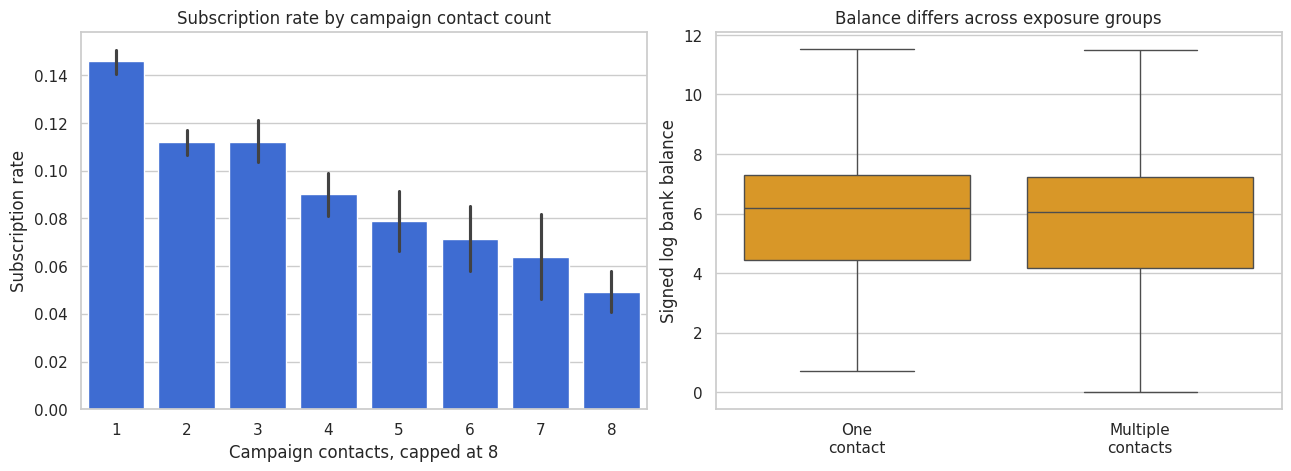

In [16]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.real_data import load_uci_bank_marketing, optional_data_note

RUN_REAL_DATA_COMPANION = True
BANK_MARKETING_SOURCE = "https://archive.ics.uci.edu/dataset/222/bank+marketing"

if RUN_REAL_DATA_COMPANION:
    bank = load_uci_bank_marketing().copy()
    bank["subscribed"] = (bank["y"] == "yes").astype(int)
    bank["multiple_contacts"] = (bank["campaign"] > 1).astype(int)
    bank["has_previous_contact"] = (bank["previous"] > 0).astype(int)
    bank["pdays_observed"] = (bank["pdays"] >= 0).astype(int)
    bank["log_balance"] = np.sign(bank["balance"]) * np.log1p(np.abs(bank["balance"]))
    bank["contact_count_capped"] = bank["campaign"].clip(upper=8)
    baseline_covariates = ["age", "log_balance", "has_previous_contact", "pdays_observed"]

    contact_summary = (
        bank.groupby("multiple_contacts")
        .agg(
            customers=("subscribed", "size"),
            subscription_rate=("subscribed", "mean"),
            mean_age=("age", "mean"),
            mean_balance=("balance", "mean"),
            prior_contact_share=("has_previous_contact", "mean"),
            housing_loan_share=("housing", lambda x: np.mean(x == "yes")),
        )
        .rename(index={0: "One contact", 1: "Multiple contacts"})
        .reset_index(names="campaign_contact_group")
    )
    smart_display(contact_summary.round(3))

    naive_lpm = smf.ols("subscribed ~ multiple_contacts", data=bank).fit(cov_type="HC1")
    adjusted_lpm = smf.ols(
        "subscribed ~ multiple_contacts + age + log_balance + has_previous_contact + pdays_observed + "
        "C(job) + C(marital) + C(education) + C(housing) + C(loan)",
        data=bank,
    ).fit(cov_type="HC1")

    adjustment_table = pd.DataFrame(
        [
            {
                "model": "Naive difference in subscription probability",
                "estimate": naive_lpm.params["multiple_contacts"],
                "std_error": naive_lpm.bse["multiple_contacts"],
                "meaning": "Raw association between repeated contact and subscription.",
            },
            {
                "model": "Adjusted linear probability model",
                "estimate": adjusted_lpm.params["multiple_contacts"],
                "std_error": adjusted_lpm.bse["multiple_contacts"],
                "meaning": "Association after observed pre-campaign covariates and basic demographics.",
            },
        ]
    )
    smart_display(adjustment_table.round(4))

    fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6), constrained_layout=True)
    sns.barplot(data=bank, x="contact_count_capped", y="subscribed", errorbar=("ci", 95), ax=axes[0], color="#2563eb")
    axes[0].set_title("Subscription rate by campaign contact count")
    axes[0].set_xlabel("Campaign contacts, capped at 8")
    axes[0].set_ylabel("Subscription rate")

    sns.boxplot(data=bank, x="multiple_contacts", y="log_balance", ax=axes[1], color="#f59e0b", showfliers=False)
    axes[1].set_xticklabels(["One\ncontact", "Multiple\ncontacts"])
    axes[1].set_title("Balance differs across exposure groups")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Signed log bank balance")
    plt.show()
else:
    optional_data_note("UCI Bank Marketing", BANK_MARKETING_SOURCE, "RUN_REAL_DATA_COMPANION")

The companion is useful precisely because the answer is not clean. Repeated contact is associated with subscription, but repeated contact also reflects targeting, customer availability, prior campaign history, and operational follow-up rules. The adjusted model changes the comparison, yet it still cannot turn this into a randomized experiment.

This is the practical lesson for regression adjustment: adjustment is strongest when it follows a credible design story. A larger formula alone is not a design.

## References

Ho, F. K. (2025). Regression adjustment for causal inference. *BMJ Medicine, 4*(1), e000816. https://doi.org/10.1136/bmjmed-2023-000816

Imbens, G. W. (2004). Nonparametric estimation of average treatment effects under exogeneity: A review. *The Review of Economics and Statistics, 86*(1), 4-29. https://doi.org/10.1162/003465304323023651

Lin, W. T. (2013). Agnostic notes on regression adjustments to experimental data: Reexamining Freedman's critique. *The Annals of Applied Statistics, 7*(1), 295-318. https://doi.org/10.1214/12-AOAS583

Rosenbaum, P. R., & Rubin, D. B. (1983). The central role of the propensity score in observational studies for causal effects. *Biometrika, 70*(1), 41-55. https://doi.org/10.1093/biomet/70.1.41

Rubin, D. B. (1974). Estimating causal effects of treatments in randomized and nonrandomized studies. *Journal of Educational Psychology, 66*(5), 688-701. https://doi.org/10.1037/h0037350